
# Статистический анализ данных

# Описание проекта:
Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки
    * абонентская плата отсутствует;
    * стоимость одной минуты поездки — 8 рублей;
    * стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra
    * абонентская плата — 199 рублей в месяц;
    * стоимость одной минуты поездки — 6 рублей;
    * стоимость старта — бесплатно.

# Цель исследования: 
Проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

# Описание данных:

В основных данных есть информация о пользователях, их поездках и подписках.

<b>Пользователи</b> — users_go.csv
* user_id - уникальный идентификатор пользователя
* name	имя пользователя
* age	возраст
* city	город
* subscription_type	тип подписки (free, ultra)

<b>Поездки</b> — rides_go.csv
* user_id - уникальный идентификатор пользователя
* distance - расстояние, которое пользователь проехал в текущей сессии (в метрах)
* duration - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
* date - дата совершения поездки

<b>Подписки </b>— subscriptions_go.csv

* subscription_type - тип подписки
* minute_price - стоимость одной минуты поездки по данной подписке
* start_ride_price - стоимость начала поездки
* subscription_fee - стоимость ежемесячного платежа

# Ход исследования:
<b>Шаг 1.</b> Загрузка данных <br> 
<b>Шаг 2.</b> Предобработка данных <br> 
<b>Шаг 3.</b> Исследовательский анализ данных <br> 
<b>Шаг 4.</b> Объединение данных <br> 
<b>Шаг 5.</b> Подсчёт выручки <br> 
<b>Шаг 6.</b> Проверка гипотез <br> 
<b>Общий вывод:</b> резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций.

In [1]:
#Импорт библиотек:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
import numpy as np

plt.rcParams['font.size'] = 13 # установка размера подписей для всех графиков 

#### Шаг 1. Загрузка данных
<b>1.1 </b>Считать CSV-файлы с данными с помощью библиотеки pandas и сохранить их в датафреймы. Пути к файлам:<br>
/datasets/users_go.csv<br>
/datasets/rides_go.csv<br>
/datasets/subscriptions_go.csv<br>
<b>1.2 </b> Вывести первые строки каждого набора данных. Изучить общую информацию о каждом датафрейме.<br>

In [2]:
#Создание дф:
users = pd.read_csv('/datasets/users_go.csv')
rides = pd.read_csv('/datasets/rides_go.csv')
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')

In [3]:
#Создание списков дф:
df_list = [users, rides, subscriptions]               #для вывода информации
df_list2 = ['users', 'rides', 'subscriptions']        #для вывода источника информации

In [4]:
#Вывод первых 5 строк датафреймов:
for i, name in zip(df_list, df_list2):
    print(f'{name}:')
    display(i.head())
    print('-~-'*15,'\n'*2)

users:


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


-~--~--~--~--~--~--~--~--~--~--~--~--~--~--~- 


rides:


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


-~--~--~--~--~--~--~--~--~--~--~--~--~--~--~- 


subscriptions:


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


-~--~--~--~--~--~--~--~--~--~--~--~--~--~--~- 




In [5]:
# Вывод основной информации:
for i, name in zip(df_list, df_list2):
    print(f'{name}:')
    i.info()
    print('-~-'*15,'\n'*2)

users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
-~--~--~--~--~--~--~--~--~--~--~--~--~--~--~- 


rides:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
-~--~--~--~--~--~--~--~--~--~--~--~--~--~--~-

<b>Вывод: </b> <br>
Созданы ДФ, созданы списки, выведены первые строки и основная информация.<br>
Наименования колонок корректны. <br>
В дф с `пользователями` представлены записи по 1565 пользователям, в дф с `поездками` информация по 18068 поездкам, в дф с `подписками` 2 записи с тарифами. Предварительно, не заполненных колонок нет.<br>
Некорректный формат данных только в дф с `поездками` в колонке `date`.

#### Шаг 2. Предобработка данных
<b>2.1 </b> Приведите столбец date к типу даты pandas.<br>

In [6]:
# Приведение столбца rides['date'] к корректному типу:
rides['date'] = pd.to_datetime(rides['date'])

# Вывод типов данных:
rides.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object

<b>2.2 </b> Создайте новый столбец с номером месяца на основе столбца date.<br>

In [7]:
# Создание колонки с месяцем:
rides['month'] = rides['date'].dt.month

# Выведем первые строки дф:
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [8]:
# Проверим за какие года есть информация:
rides['date'].dt.year.unique()

array([2021])

<b>Вывод: </b><br>
Данные представлены за 2021 год. Пересечений по месяцам между годами не ожидается. Продолжаем работу.

<b>2.3 </b> Проверьте наличие пропущенных значений и дубликатов в датафреймах. Обработайте их, если такие значения присутствуют.<br>

In [9]:
#Проверка пропущенных значений в дф:
for i, name in zip(df_list, df_list2):
    print(f'Проверка пропущенных значений в {name}:')
    print(i.isna().sum())
    print('-~-'*10,'\n')

Проверка пропущенных значений в users:
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64
-~--~--~--~--~--~--~--~--~--~- 

Проверка пропущенных значений в rides:
user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64
-~--~--~--~--~--~--~--~--~--~- 

Проверка пропущенных значений в subscriptions:
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64
-~--~--~--~--~--~--~--~--~--~- 



<b>Вывод: </b><br>Не заполненные поля не обнаружены.

In [10]:
#Проверка всех дф на дубли:
for i, name in zip(df_list, df_list2):
    print(f'Количество явных дублей в {name}: {i.duplicated().sum()}')
    print('-~-'*10,'\n')

Количество явных дублей в users: 31
-~--~--~--~--~--~--~--~--~--~- 

Количество явных дублей в rides: 0
-~--~--~--~--~--~--~--~--~--~- 

Количество явных дублей в subscriptions: 0
-~--~--~--~--~--~--~--~--~--~- 



В дф `users` обнаружен 31 дубль. 

In [11]:
# Выведем список полных дублей:
users_b = users[users.duplicated() == False]
print(f'Всего записей в дф users: {len(users)}')
print(f'Записей без дублей в дф users: {len(users_b)}')
print(f'Доля оставшихся данных: {len(users_b)/len(users):.2%}')

Всего записей в дф users: 1565
Записей без дублей в дф users: 1534
Доля оставшихся данных: 98.02%


После очистки остаётся более 98%, можно удалить дубли и продолжить работу.

In [12]:
# Очистка дф users от дублей:
users = users.drop_duplicates().reset_index(drop=True)

print('Количество оставшихся дублей:',users.duplicated().sum())

Количество оставшихся дублей: 0


In [13]:
# Проверим на неявные дубли таблицу с поездками по колонкам 'user_id' и 'date'. Выведем все записи с неявными дублями:
rides[rides.duplicated(keep = False,subset=['user_id','date']) == True].sort_values(['user_id', 'date'])

,user_id,distance,duration,date,month
104,10,3782.600524,16.350355,2021-07-02,7
105,10,1409.589386,15.020549,2021-07-02,7
436,47,2932.359316,12.766983,2021-06-19,6
437,47,3261.866673,19.248593,2021-06-19,6
1109,119,2751.649289,18.008996,2021-04-25,4
...,...,...,...,...,...
17649,1506,2619.868392,19.287684,2021-08-29,8
18046,1533,3848.116660,27.989727,2021-03-26,3
18047,1533,2500.091900,20.714680,2021-03-26,3
18051,1533,2309.366191,17.773415,2021-07-28,7


In [14]:
x = len(rides[rides.duplicated(subset=['user_id','date']) == True])
y = len(rides)
print(f'Количество неявных дублей составляет: {x} строк')
print(f'Или {x/y:.1%} от общего количества')


Количество неявных дублей составляет: 292 строк
Или 1.6% от общего количества


In [15]:
rides[rides.duplicated(keep = False,subset=['user_id','date']) == True]

,user_id,distance,duration,date,month
104,10,3782.600524,16.350355,2021-07-02,7
105,10,1409.589386,15.020549,2021-07-02,7
436,47,2932.359316,12.766983,2021-06-19,6
437,47,3261.866673,19.248593,2021-06-19,6
1109,119,2751.649289,18.008996,2021-04-25,4
...,...,...,...,...,...
17649,1506,2619.868392,19.287684,2021-08-29,8
18046,1533,3848.116660,27.989727,2021-03-26,3
18047,1533,2500.091900,20.714680,2021-03-26,3
18051,1533,2309.366191,17.773415,2021-07-28,7


Обнаружены не явные 292 дубля (1.62% от общего количества записей), при этом есть 4 пользователя, которые выполняли не по 2 поездки за 1 дату, а 3. Удалять не буду, продолжительность поездки и дистанция слишком различаются.

Проверим дф на отклонения в значениях. 
Построим диаграммы размахов по каждому дф (кроме subscription - там всего 2 записи):

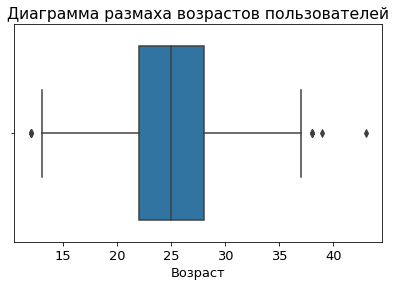

In [16]:
# Диаграмма размаха по дф 'users':
plt.figure(figsize=(6.6, 4))
ax = sns.boxplot(x=users['age'])#, 
ax.set_title('Диаграмма размаха возрастов пользователей')
ax.set_xlabel('Возраст')            
plt.show()

По диаграмме размаха видно, что есть хвосты, построим гистограммы, чтобы изучить распределение хвостов.

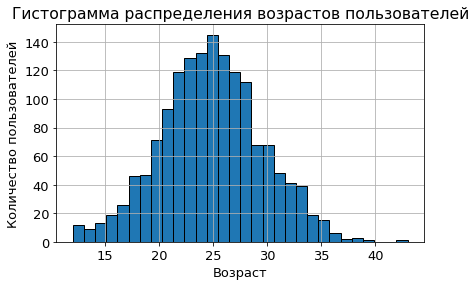

In [17]:
# Гистограмма по дф 'users':
(users['age'].hist(figsize=(6.6, 4), bins = 30, edgecolor = 'black')
    .set(title = 'Гистограмма распределения возрастов пользователей', 
         ylabel = 'Количество пользователей', 
         xlabel = 'Возраст'))
plt.show()

Смущают пользователи с возрастом от 40 лет. Рассмотрим пользователей, возраст которых 39 лет или старше.

In [18]:
#Выведем список пользователей 39 лет и старше:
users[users['age']>=39]

,user_id,name,age,city,subscription_type
961,962,Дмитрий,39,Москва,free
1201,1202,Ангелина,43,Москва,free


Как видно, отсутствуют пользователи в возрасте от 40 до 42 лет. В принципе, можно сказать, что возраст в 43 года из статистики выбивается, и если удалить, ничего существенно не изменится, но я предпочту не очищать базу от пользователя. 

Проверим на наличие всплесков дф `rides` колонки с `расстоянием` и `потреченным временем`.

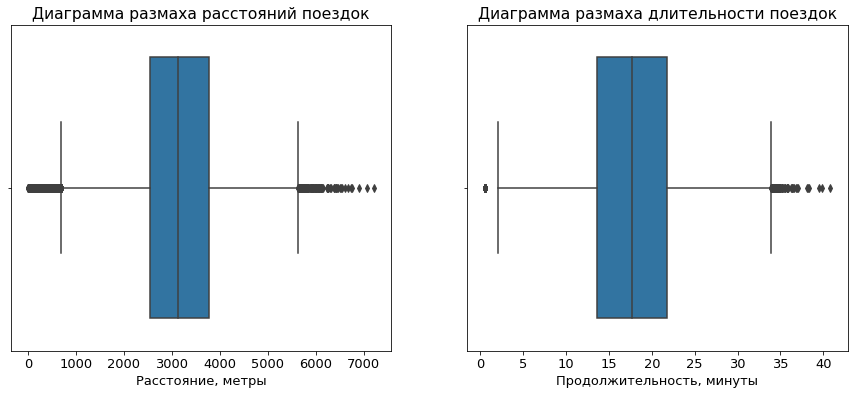

In [19]:
# Диаграммы размаха по дф 'rides':
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Общая подпись к графикам:
#plt.suptitle('  ', fontsize=20)

# Строим диаграммы размаха для указанных в названии величин
ax[0] = (sns.boxplot(data = rides, x = 'distance', ax=ax[0])
    .set(title = 'Диаграмма размаха расстояний поездок',
     xlabel='Расстояние, метры')
        )
ax[1] = (sns.boxplot(data = rides, x = 'duration', ax=ax[1])
.set(title = 'Диаграмма размаха длительности поездок',
     xlabel='Продолжительность, минуты')      
        )
plt.show()

Диаграммы размаха снова показали хвосты. Построим гистограммы.

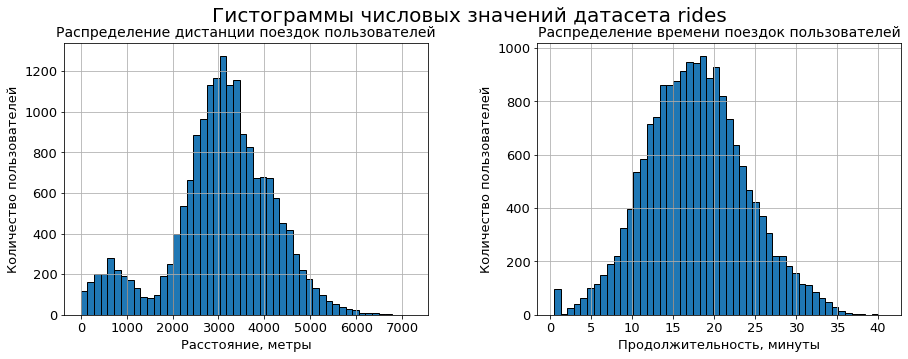

In [20]:
# Гистограммы по дф rides:
ax = rides[['distance','duration']].hist(figsize=(15,5), bins = 50, edgecolor = 'black')

# Общая подпись к графикам:
plt.suptitle('Гистограммы числовых значений датасета rides', fontsize=20)

# Подписи к первому графику:
ax[0,0].set_title('Распределение дистанции поездок пользователей', fontsize=14)
ax[0,0].set_ylabel('Количество пользователей')
ax[0,0].set_xlabel('Расстояние, метры')

# Подписи ко второму графику:
ax[0,1].set_title('Распределение времени поездок пользователей', fontsize=14)
ax[0,1].set_ylabel('Количество пользователей')
ax[0,1].set_xlabel('Продолжительность, минуты')

plt.show()

В дф `rides` выявлен всплеск в колонке `duration`. На гистограмме слишком сильно выделяется столбец с минимальной длительностью поездки. Рассмотрим такие поездки отдельно - отберем поездки с длительность до двух минут включительно:   

In [21]:
#Сохраним дф, в которой длительность поездки составила менее 2 минут:
short_time_rides = rides[rides['duration'] <= 2].sort_values('distance', ascending = False)

#Выведем таблицу:
short_time_rides

,user_id,distance,duration,date,month
16309,1411,7211.007745,0.5,2021-04-15,4
17242,1477,6724.932981,0.5,2021-01-12,1
11385,1057,6601.197575,0.5,2021-02-07,2
13701,1224,6414.516026,0.5,2021-07-15,7
14574,1285,6316.574814,0.5,2021-09-25,9
...,...,...,...,...,...
14342,1268,4177.139336,0.5,2021-06-09,6
9698,937,4169.066800,0.5,2021-12-12,12
10692,1006,4106.278268,0.5,2021-10-31,10
17909,1524,4103.998874,0.5,2021-06-18,6


Таких поездок оказалось 95, подтянем информацию из дф `users`, чтобы понять что за тип подписки там хранится.

In [22]:
short_time_rides = short_time_rides.merge(users, on='user_id', how='left')

In [23]:
short_time_rides.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type
0,1411,7211.007745,0.5,2021-04-15,4,Александр,20,Пятигорск,free
1,1477,6724.932981,0.5,2021-01-12,1,Ян,17,Сочи,free
2,1057,6601.197575,0.5,2021-02-07,2,Адель,26,Москва,free
3,1224,6414.516026,0.5,2021-07-15,7,Александр,25,Пятигорск,free
4,1285,6316.574814,0.5,2021-09-25,9,Станислав,27,Пятигорск,free


Данные подтянулись корректно. Посмотрим какие значения находятся в колонке `subscription_type` (`тип подписки`) и `duration` (`длительность поездки`), а так же сколько каждый из них раз повторяется.


In [24]:
print('Содержимое колонки "тип подписки":','\n',short_time_rides['subscription_type'].value_counts(),'\n'*2)
print('Содержимое колонки "длительность поездки":','\n',short_time_rides['duration'].value_counts())

Содержимое колонки "тип подписки": 
 free    95
Name: subscription_type, dtype: int64 


Содержимое колонки "длительность поездки": 
 0.5    95
Name: duration, dtype: int64


Продолжительность всех 95 поездок составила 0.5 минуты, тип подписки везде - `free` (без платной подписки), при этом пройденое расстояние по таким поездкам составило от полных 4 км до 7 км с лишним. <br>
Считаю значение длительности поездки в `0.5` минут `"заглушкой"`, которая была присвоена, предположительно из-за того, что данных не было вовсе по какой-то причине.
Посмотрим на сколько данные в указанных поездках необходимы: 
Предположим, если доля указанных поездок в количественном выражении менее 5% от общего числа, то рассмотрим возможность убрать их из дф.


In [25]:
len_rides = len(rides)
len_short_time_rides = len(rides[rides['duration'] == 0.5])

print(f'Доля поездок с "заглушкой" вместо корректной продолжительности составило {len_short_time_rides/len_rides:.1%} от общего числа поездок.')

Доля поездок с "заглушкой" вместо корректной продолжительности составило 0.5% от общего числа поездок.


Считаю, что 0.5% - не большая доля поездок, их отфильтровывание не испортит итоговые данные, а наоборот предотвратит возможные ошибки в расчётах, т.к. поездки на расстояеия по 4-7 км вряд ли получится преодолеть за полминуты на самокате, да и стоимость таких поездок в 58 рублей тоже вызывает сомнение.

In [26]:
#Исключаем данные с длительностью поездки = 0.5:
rides = rides[rides['duration'] != 0.5].reset_index(drop=True)

In [27]:
# Основная инфо по дф:
rides.info()
print('\n'*2)

# Вывод первых строк:
display(rides.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17973 entries, 0 to 17972
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   17973 non-null  int64         
 1   distance  17973 non-null  float64       
 2   duration  17973 non-null  float64       
 3   date      17973 non-null  datetime64[ns]
 4   month     17973 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 702.2 KB





,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


<b>Вывод:</b><br>Очистка от всплесков прошла успешно.

<b>Вывод по шагу 2:</b><br>
В шаге 2 были проделаны следующие этапы:
* был изменен тип данных в колонке `date` датафрейма с `поездками` на корректный.
* была создана отдельная колонка с номером месяца в датафрейме с `поездками`.
* была проведена проверка всех 3х датафреймов на наличие пропущенных данных - не выявлены. 
* была проведена проверка всех 3х датафреймов на наличие явных дубликатов - выявлены 31 задвоение (чуть менее 2% данных) в датайрейме с `пользователями`, дф от них очищен. 
* выявлены несколько пользователей, которые в течение дня пользовались услугами сервиса несколько раз (потенцильные дубли) - не удалял.
* была проведена проверка дф с `поездками`и с `пользователями` на "всплески" - выявлены всплески в колонке `duration`дф `rides`. Дф очищен от всплесков. 

#### Шаг 3. Исследовательский анализ данных 


<b>3.1 </b> Рассмотрим частоту встречаемости городов:

In [28]:
#Выведем таблицу:
users_city_pivot = users.pivot_table(index = 'city', values = 'user_id', aggfunc = 'count').sort_values('user_id', ascending = False).reset_index().rename(columns={'user_id':'count'})
users_city_pivot['ratio,%'] = round(users_city_pivot['count'] / len(users)*100, 2)

display(users_city_pivot)

,city,count,"ratio,%"
0,Пятигорск,219,14.28
1,Екатеринбург,204,13.30
2,Ростов-на-Дону,198,12.91
3,Краснодар,193,12.58
4,Сочи,189,12.32
5,Омск,183,11.93
6,Тюмень,180,11.73
7,Москва,168,10.95


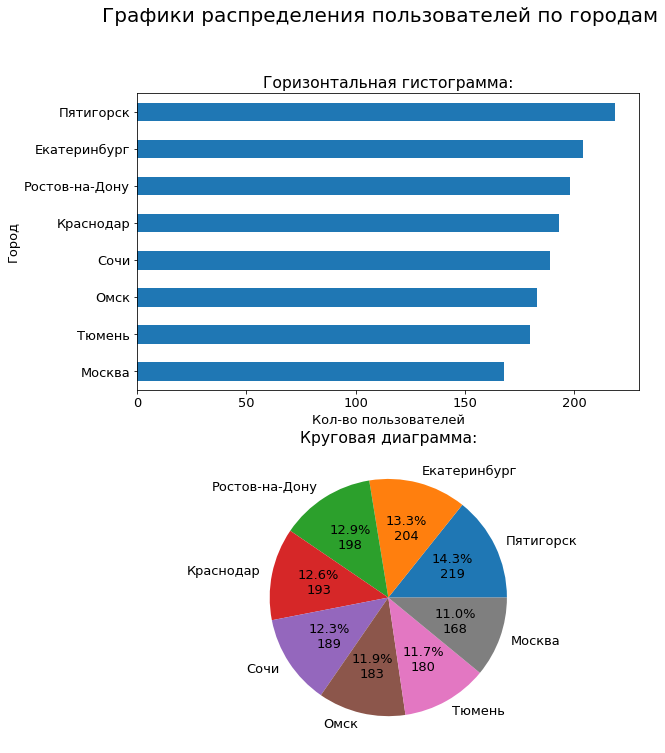

In [29]:
# Создадим поле для графиков распределения пользователей по городам:
fig, ax = plt.subplots(2, 1, figsize=(9, 12))

# Общая подпись на все графики
plt.suptitle('Графики распределения пользователей по городам', fontsize=20)

# Создадим горизонтальную гистограмму на основании сводной таблицы:
(users.pivot_table(index = 'city', values = 'user_id', aggfunc = 'count')
    .sort_values('user_id', ascending = True)
    .plot(kind='barh',ax=ax[0], legend = False))

# Добавим подписи к графику 1:
ax[0].set_title(f'Горизонтальная гистограмма:')
ax[0].set_xlabel('Кол-во пользователей')
ax[0].set_ylabel('Город')

# Создадим график "пирог" с добавленными подписями с количеством пользователей и долей:
(plt.pie(users_city_pivot['count'], labels=users_city_pivot['city'],
         autopct=lambda p : '{:.1f}%\n{:,.0f}'.format(p,p * sum(users_city_pivot['count'])/100)))
ax[1].set_title('Круговая диаграмма:')

plt.show()

<b> Вывод:</b> <br>
Всего в дф с пользователями представлено 8 городов, доли городов различаются не значительно (от 11% в Москве и до 14.4% в Пятигорске). Можно сказать, что был взят идентичный срез пользователей по всем городам. 

<b>3.2 </b> Рассмотрим соотношение пользователей с подпиской и без подписки:

In [30]:
#Выведем таблицу:
users_subscription_pivot = users.pivot_table(index = 'subscription_type', values = 'user_id', aggfunc = 'count').sort_values('user_id', ascending = False).reset_index().rename(columns={'user_id':'count'})
users_subscription_pivot['ratio,%'] = round(users_subscription_pivot['count'] / len(users)*100, 2)

display(users_subscription_pivot)

,subscription_type,count,"ratio,%"
0,free,835,54.43
1,ultra,699,45.57


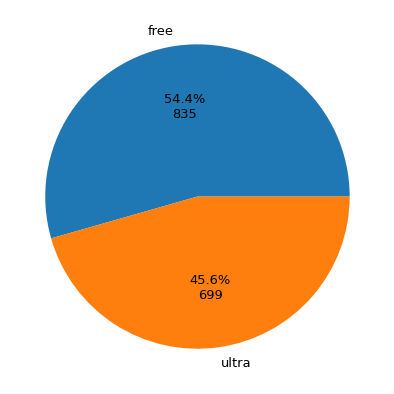

In [31]:
plt.figure(figsize=(7, 7))
plt.pie(users_subscription_pivot['count'], 
        labels=users_subscription_pivot['subscription_type'],
        autopct=lambda p : '{:.1f}%\n{:,.0f}'.format(p,p * sum(users_subscription_pivot['count'])/100))
plt.show()

<b> Вывод:</b> <br>
Всего в дф с пользователями представлено 2 тарифа. Итоговая разница в долях также не значительна - менее 10% (54.1% бесплатные подписки против 45.9% - бесплатных подписок).

<b>3.3 </b> Рассмотрим возраст пользователей;<br>

In [32]:
#Выведем таблицу:
users_age_pivot = users.pivot_table(index = 'age', values = 'user_id', aggfunc = 'count').sort_values('user_id', ascending = False).reset_index().rename(columns={'user_id':'count'})
users_age_pivot['ratio,%'] = round(users_age_pivot['count'] / len(users)*100, 2)

display(users_age_pivot.head(10))

,age,count,"ratio,%"
0,25,145,9.45
1,24,132,8.60
2,26,131,8.54
3,23,129,8.41
4,27,119,7.76
5,22,119,7.76
6,28,112,7.30
7,21,93,6.06
8,20,71,4.63
9,30,68,4.43


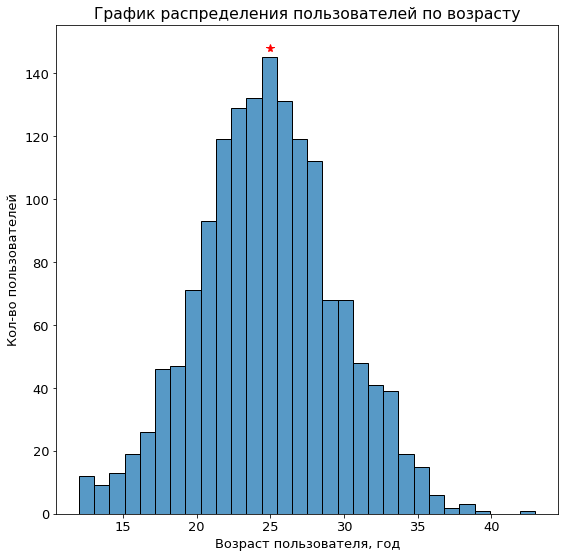

In [33]:
# Создадим гистограмму:
plt.figure(figsize=(9, 9))
ax = sns.histplot(data=users, x='age', edgecolor = 'black')
ax.set_title('График распределения пользователей по возрасту')
ax.set_xlabel('Возраст пользователя, год')
ax.set_ylabel('Кол-во пользователей')
ax.plot(25, 148, "*", markersize=8, color="r")
plt.show()

<b> Вывод:</b> <br>
В принципе, можно сказать, что основной частью самокатов являются пользователи возрастной группы от 20 до 30 лет. Больше всего пользователей 25 лет (9.5% всех пользователей), на графике выделены звездой. 

<b>3.4 </b> Рассмотрим расстояние, которое пользователь преодолел за одну поездку:<br>


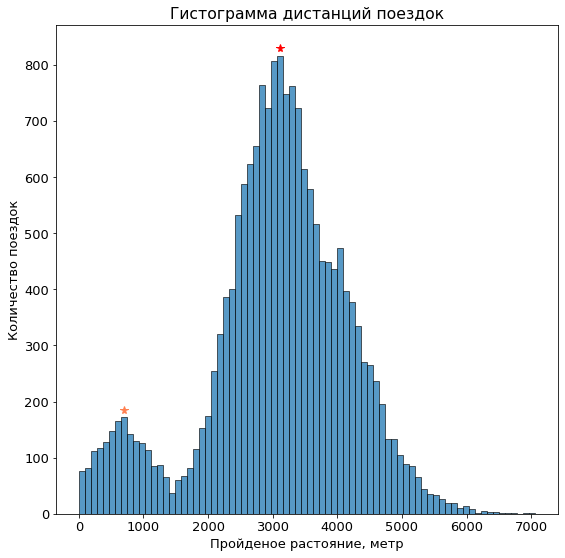

In [34]:
# Выведем гистограмму:
plt.figure(figsize=(9, 9))
ax = sns.histplot(data=rides, x='distance', edgecolor = 'black')
ax.set_title('Гистограмма дистанций поездок')
ax.set_xlabel('Пройденое растояние, метр')
ax.set_ylabel('Количество поездок')
ax.plot(3120, 830, "*", markersize=8, color="red")
ax.plot(700, 185, "*", markersize=8, color="coral")
plt.show()

Выведем 10 строк с информацией о поездках дистанцией до 30 метров.

In [35]:
# Рассмотрим поездки с крайне маленькими расстояниями:
rides[rides['distance']<=50].sort_values('duration', ascending = False).head(10)

,user_id,distance,duration,date,month
6609,707,28.793204,14.143966,2021-09-12,9
15790,1381,31.391295,14.099130,2021-06-29,6
10315,982,43.690381,13.201648,2021-07-21,7
11518,1069,44.016496,13.110041,2021-06-20,6
11812,1091,15.630873,13.044660,2021-03-29,3
9413,918,38.711151,11.165905,2021-06-08,6
16325,1417,44.728663,10.127796,2021-09-20,9
13878,1240,15.000606,10.045002,2021-08-20,8
7824,796,7.097072,10.026614,2021-11-26,11
11508,1069,0.855683,10.001902,2021-01-31,1


<b>Вывод: </b><br>
Пик количества поездок находится примерно в 3х км. Так же существует, пик примерно в 700 метрах, при этом, существуют поездки до 50 метров, а длительность времени таких поездок, иногда превышает 10 минут (минимальное расстояние составило менее метра). Полагаю, может быть связано с тем, что самокат привязан к координатам gps, а человеку необходимо было вернуться после посещения места, соответственно, завершал поездку он уже после возвращения (ну или передумал ехать и забыл завершить поездку).

<b>3.5 </b> Рассмотрим продолжительность поездок.

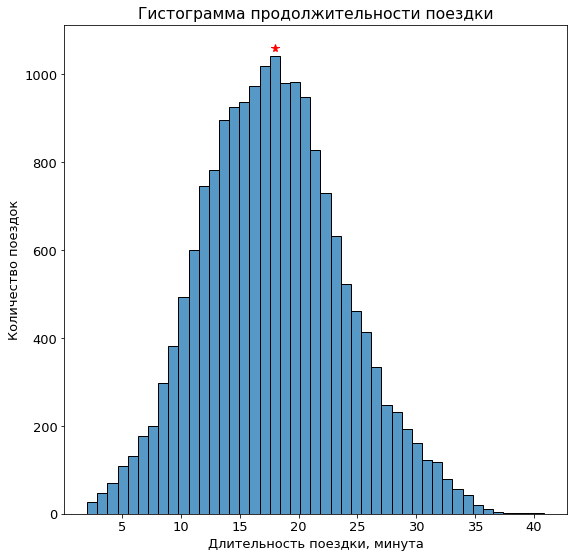

In [36]:
plt.figure(figsize=(9, 9))
ax = sns.histplot(data=rides, x='duration', edgecolor = 'black', bins = 45)
ax.set_title('Гистограмма продолжительности поездки')
ax.set_xlabel('Длительность поездки, минута')
ax.set_ylabel('Количество поездок')
ax.plot(18, 1060, "*", markersize=8, color="r")
plt.show()

<b>Вывод: </b><br>Пик поездок по продолжительности времени расположен примерно на 18 минутах, хотя этот пик условный - на интервале от 16 до 20 минут колебания не значительные.

<b>Вывод по шагу 3: </b><br>
`Города`: всего в дф присутсвует информация по 8 городам, распределение по пользователям на город различается не значительно: от 168 человек на город (11%) в Москве, до 219 людей в Пятигорске (14.3%).<br>
`Подписка`: пользователей, которые пользуются сервисом без подписки в датафрейме - 835 человек (54.4%), людей без подписки - 699 (45.6%).<br>
`Возраст`: в датафрейме представлены пользователи от 12 до 43 лет, при этом пользователей с возрастом 40 по 42 года в базе нет. Наибольшее количество пользователей 25 летнего возраста (9.5% всех пользователей), средний возраст - 24.9. Можно сказать, что основная масса пользователей примерно в возрасте от 20 до 30 лет включительно.<br>
`Дистанция`: в базе представлено почти 18000 поездок после очистки, максимальная дистанция поездки составила более 7 км. Большая часть пользователей перемешается по средствам сервиса на расстояние примерно от 2 до 5 км, при этом пик находится примерно в 3200 метров. Также существует небольшая часть поездок на расстояние на небольшую дистанцию до 1.5 км с пиком в 700 метров примерно. <br>
`Длительность`: по продолжительности поездки можно отметить, что больше всего поездок длились примерно 18 минут, максимальная продолжительность составила 40 минут с лишним, минимальная продолжительность поездки (после очистки от 95 поездок с продолжительностью в 0.5 минуты) составила чуть больше 2 минут. 

#### Шаг 4. Объединение данных 


<b>4.1 </b> Объединение данных о пользователях, поездках и подписках в один датафрейм. Для этого воспользуемся методом merge().

In [37]:
#Выведем размепры трех дф:
print(f'Размер дф rides: {rides.shape}')
print(f'Размер дф users: {users.shape}')
print(f'Размер дф subscriptions: {subscriptions.shape}')

Размер дф rides: (17973, 5)
Размер дф users: (1534, 5)
Размер дф subscriptions: (2, 4)


3 дф можно имеют следующие общие колонки, объединение можно провести по ним:<br>
`users['user_id']` и `rides['user_id']`.<br>
А также`users['subscription_type']` и `subscriptions['subscription_type']`.

Но перед объединением стоит проверить указанные колонки на совпадение данных.

In [38]:
# Проверим количество пользователей на совпадение
if len(users['user_id'].unique()) == len(rides['user_id'].unique()):
    print('Количество пользователей совпадает')
else:
    print('Количество пользователей не совпадает')

# проверим совпадают ли пользователи в списках
if (users['user_id'].isin(rides['user_id']).unique() == rides['user_id'].isin(users['user_id']).unique()) == True:
    print('Списки с пользователями совпадают')
else:
    print('Списки с пользователями не совпадают')


Количество пользователей совпадает
Списки с пользователями совпадают


Списки в колонках `'user_id'`совпадают. Применив метод `.merge()` объединим 2 дф. 

In [39]:
#Объединение дф 'rides' и 'users' в общий дф: 
df = rides.merge(users, on='user_id', how='left')

#Вывод сообщения с размером дф:
print('Размер итогового дф составляет:', df.shape)

#Вывод 5 строк дф:
display(df.head(5))

Размер итогового дф составляет: (17973, 9)


,user_id,distance,duration,date,month,name,age,city,subscription_type
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra


Объединение прошло успешно.

Проведем второе объединение по колонке `subscription_type`.

In [40]:
df = df.merge(subscriptions, on='subscription_type', how='left')

In [41]:
#Вывод сообщения с размером дф:
print('Размер итогового дф после второго объединения составляет:', df.shape) 

#Вывод первых 5 строк дф:
display(df.head(5))

#Выведем основную информацию:
df.info()

Размер итогового дф после второго объединения составляет: (17973, 12)


,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
Int64Index: 17973 entries, 0 to 17972
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            17973 non-null  int64         
 1   distance           17973 non-null  float64       
 2   duration           17973 non-null  float64       
 3   date               17973 non-null  datetime64[ns]
 4   month              17973 non-null  int64         
 5   name               17973 non-null  object        
 6   age                17973 non-null  int64         
 7   city               17973 non-null  object        
 8   subscription_type  17973 non-null  object        
 9   minute_price       17973 non-null  int64         
 10  start_ride_price   17973 non-null  int64         
 11  subscription_fee   17973 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


<b>Вывод:</b><br>
Объединение прошло успешно, ничего лишнего не появилось в результате, требуемое добавилось.

<b>4.2 </b> Создайте ещё два датафрейма из датафрейма, созданного на этапе 4.1:<br>
c данными о пользователях без подписки;<br>
с данными о пользователях с подпиской.<br>

In [42]:
# Создание дф с пользователями без подписки:
free_df = df[df['subscription_type'] == 'free'].reset_index(drop = True)

#Вывод 5 строк дф без подписки:
display(free_df.head(5))

#Вывод основной информации:
free_df.info()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,700,2515.690719,14.944286,2021-01-02,1,Айдар,22,Омск,free,8,50,0
1,700,846.932642,16.234663,2021-02-01,2,Айдар,22,Омск,free,8,50,0
2,700,4004.434142,20.016628,2021-02-04,2,Айдар,22,Омск,free,8,50,0
3,700,1205.911290,9.782872,2021-02-10,2,Айдар,22,Омск,free,8,50,0
4,700,3047.379435,17.427673,2021-02-14,2,Айдар,22,Омск,free,8,50,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11473 entries, 0 to 11472
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11473 non-null  int64         
 1   distance           11473 non-null  float64       
 2   duration           11473 non-null  float64       
 3   date               11473 non-null  datetime64[ns]
 4   month              11473 non-null  int64         
 5   name               11473 non-null  object        
 6   age                11473 non-null  int64         
 7   city               11473 non-null  object        
 8   subscription_type  11473 non-null  object        
 9   minute_price       11473 non-null  int64         
 10  start_ride_price   11473 non-null  int64         
 11  subscription_fee   11473 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.1+ MB


In [43]:
# Создание дф с пользователями с подпиской:
ultra_df = df[df['subscription_type'] == 'ultra'].reset_index(drop = True)

#Вывод 5 строк дф с подпиской:
display(ultra_df.head(5))

#Вывод основной информации:
ultra_df.info()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   distance           6500 non-null   float64       
 2   duration           6500 non-null   float64       
 3   date               6500 non-null   datetime64[ns]
 4   month              6500 non-null   int64         
 5   name               6500 non-null   object        
 6   age                6500 non-null   int64         
 7   city               6500 non-null   object        
 8   subscription_type  6500 non-null   object        
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 609.5+ KB


<b>Вывод:</b><br>
Создание 2 дф с разными подписками прошло успешно. 



<b>4.3 </b> Визуализируйте информацию о расстоянии и времени поездок для пользователей обеих категорий.<br>

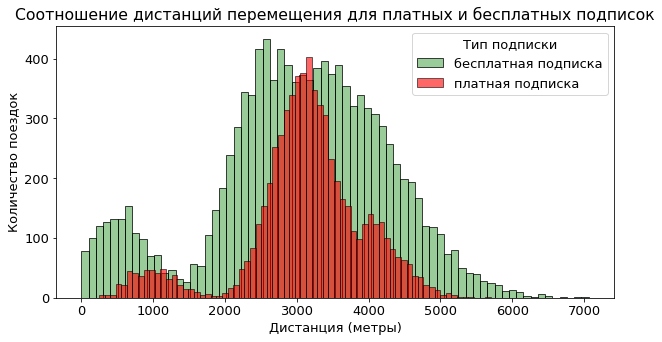

In [44]:
plt.figure(figsize = (10,5))

sns.histplot(data = free_df['distance'], color = 'green', label = 'бесплатная подписка', alpha = 0.4, bins = 70)
sns.histplot(data = ultra_df['distance'], color = 'red', label = 'платная подписка', alpha = 0.6, bins = 70)

plt.title('Соотношение дистанций перемещения для платных и бесплатных подписок')        
plt.xlabel('Дистанция (метры)' )
plt.ylabel('Количество поездок')
plt.legend(title='Тип подписки')

plt.show()

In [45]:
# Построим таблицу с основными данными: 
distance = pd.merge(free_df['distance'].describe(), ultra_df['distance'].describe(), left_index=True, right_index=True, suffixes=('-free', '-ultra'))
distance.rename(columns = {'distance-free':'free','distance-ultra':'ultra'})

,free,ultra
count,11473.000000,6500.000000
mean,3028.374239,3115.445388
std,1235.541051,836.895330
min,0.855683,244.210438
25%,2360.878149,2785.444017
50%,3102.083025,3148.637229
75%,3883.979311,3560.574425
max,7066.003772,5699.769662


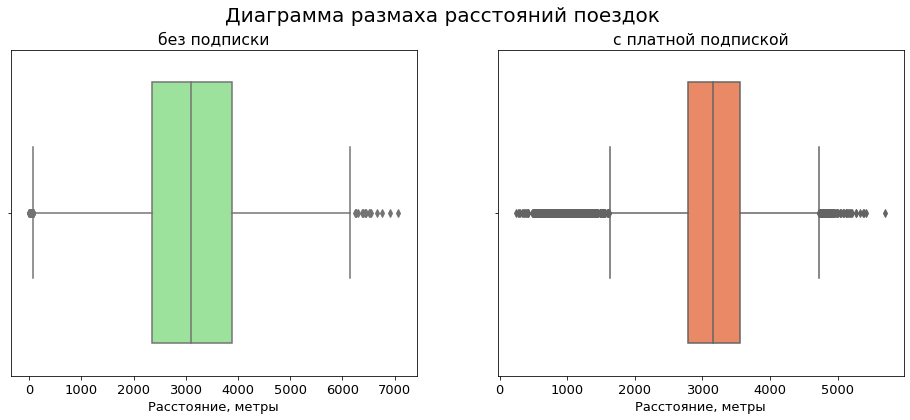

In [46]:
# Визуализируем данные из таблицы. Построим диаграммы размаха по дистанции поездки с разбивкой по видам подписки:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Общая подпись к графикам:
plt.suptitle('Диаграмма размаха расстояний поездок', fontsize=20)

# Строим диаграммы размаха для указанных в названии величин
ax[0] = (sns.boxplot(data = free_df, x = 'distance', ax=ax[0], color = 'lightgreen')
    .set(title = 'без подписки',
     xlabel='Расстояние, метры')
        )
ax[1] = (sns.boxplot(data = ultra_df, x = 'distance', ax=ax[1], color = 'coral')
.set(title = 'с платной подпиской',
     xlabel='Расстояние, метры')      
        )
plt.show()

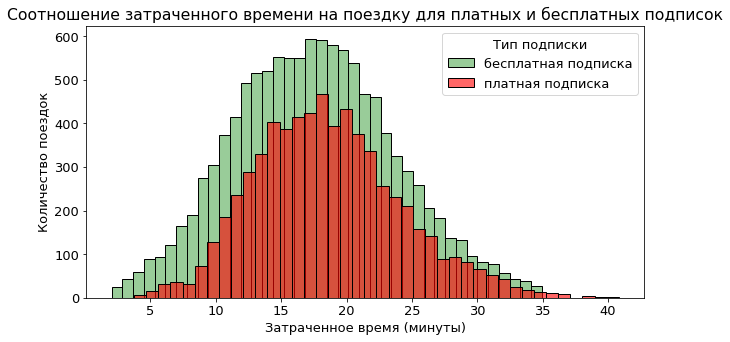

In [47]:
plt.figure(figsize = (10,5))

sns.histplot(data = free_df['duration'], color = 'green', label = 'бесплатная подписка', alpha = 0.4, bins = 40)
sns.histplot(data = ultra_df['duration'], color = 'red', label = 'платная подписка', alpha = 0.6, bins = 40)



plt.title('Соотношение затраченного времени на поездку для платных и бесплатных подписок')        
plt.xlabel('Затраченное время (минуты)' )
plt.ylabel('Количество поездок')
plt.legend(title='Тип подписки')

plt.show()

In [48]:
duration = pd.merge(free_df['duration'].describe(), ultra_df['duration'].describe(), left_index=True, right_index=True, suffixes=('-free', '-ultra'))
duration.rename(columns = {'duration-free':'free','duration-ultra':'ultra'})

,free,ultra
count,11473.000000,6500.000000
mean,17.530771,18.541985
std,6.162609,5.572048
min,2.035632,3.760353
25%,13.085688,14.524654
50%,17.383807,18.178153
75%,21.638038,21.884129
max,34.948498,40.823963


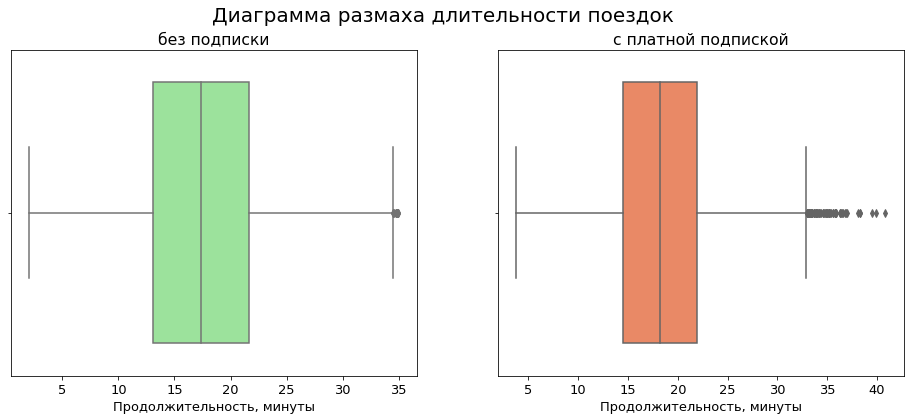

In [49]:
# Визуализируем данные из таблицы. Построим диаграммы размаха по продолжительности поездки с разбивкой по видам подписки:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Общая подпись к графикам:
plt.suptitle('Диаграмма размаха длительности поездок', fontsize=20)

# Строим диаграммы размаха для указанных в названии величин
ax[0] = (sns.boxplot(data = free_df, x = 'duration', ax=ax[0], color = 'lightgreen')
    .set(title = 'без подписки',
     xlabel='Продолжительность, минуты')
        )
ax[1] = (sns.boxplot(data = ultra_df, x = 'duration', ax=ax[1], color = 'coral')
.set(title = 'с платной подпиской',
     xlabel='Продолжительность, минуты')      
        )
plt.show()

<b>Вывод: </b><br>
Доля поездок без платной подписки составляет 63% с лишним, при этом доля пользователей без подписки - 54.4%, из чего можно сделать вывод, что люди без платной подписки чаще повторно пользуются услугами сервиса (исходя из выборок данных).<br>
<b>По пройденому расстоянию за поездку:<br></b>
Пользователи с платной подпиской предпочитают поездки до 4.5км включительно, чаще всего перемещаются на расттояние в 3км, на расстоянии 2км наблюдается почти нулевой спрос на сервис. У пользователей без платной подписки явных предпочтений в дистанции перемещения меньше - наблюдается более широкое размазывание пика на графике, то есть, если у платных пользователей пик - 3км, то у "бесплатных" - 2,5 - 3,7 км.<br>
<b>По затраченному времени на поездку:<br></b>
В целом, различия в затраченном времени от подписки зависит не значительно, единственное, что можно отметить - пользователи без платной подписки тратят на поездку чуть меньше времени.

<b>Вывод по шагу 4: </b><br>
`Объединение в датафрейм`: используя метод `merge()`, 3 датафрейма были объединены в общий под названием `df`.<br>
`Создание 2х дф по подпискам`: далее основной `df` был разбит на два дополнительных: с данными по пользователям, которые пользовались подпиской и по пользователям, которые пользовались сервисом без подписки.<br>
`Визуализация данных`: построены графики по количеству поездок с платной подпиской и без по расстоянию поездки и её продолжительности.Выведены таблицы с основной информацией по тем же критериям, визуализированы указанные данные. Сделаны выводы:
Пользователи с платной подпиской предпочитают ехать дольше, но на меньшее расстояние, пользователи без платной подписки, чаще перемещется на большие расстояния, но за меньшее время. Полагаю, что если бы пользователей с платной подпиской было бы больше, то пешеходы бы страдали от этого сильно меньше.

#### Шаг 5. Подсчёт выручки


<b>5.1 </b> Создать датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4: 
* суммарное расстояние, 
* количество поездок 
* суммарное время для каждого пользователя за каждый месяц.<br>

Перед созданием дф, необходимо привести значения, указанные в колонке `duration`, к требуемому виду, округлив до целого числа вверх.

In [50]:
# Округлив вверх, изменим тип данных колонки с 'float64' на 'int64':
df['duration'] = np.ceil(df['duration']).astype(int)
df.head(5)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,26,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,16,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,7,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,19,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,27,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [51]:
#Создадим 'grouped_df', сгруппировав данные:
grouped_df = df.groupby(['user_id','name', 'age', 'city', 'month','subscription_type','minute_price','start_ride_price','subscription_fee']).agg({'distance' : 'sum', 'date' : 'count', 'duration' : 'sum' })
grouped_df = grouped_df.reset_index().rename(columns= {'distance' : 'sum_distance', 'date' : 'count_rides', 'duration' : 'sum_duration'})
grouped_df.head(10)

,user_id,name,age,city,month,subscription_type,minute_price,start_ride_price,subscription_fee,sum_distance,count_rides,sum_duration
0,1,Кира,22,Тюмень,1,ultra,6,0,199,7027.511294,2,42
1,1,Кира,22,Тюмень,4,ultra,6,0,199,754.159807,1,7
2,1,Кира,22,Тюмень,8,ultra,6,0,199,6723.470560,2,46
3,1,Кира,22,Тюмень,10,ultra,6,0,199,5809.911100,2,32
4,1,Кира,22,Тюмень,11,ultra,6,0,199,7003.499363,3,56
5,1,Кира,22,Тюмень,12,ultra,6,0,199,6751.629942,2,28
6,2,Станислав,31,Омск,3,ultra,6,0,199,10187.723006,3,63
7,2,Станислав,31,Омск,4,ultra,6,0,199,6164.381824,2,40
8,2,Станислав,31,Омск,6,ultra,6,0,199,3255.338202,1,14
9,2,Станислав,31,Омск,7,ultra,6,0,199,6780.722964,2,48



<b>5.2 </b> Добавить в датафрейм столбец с помесячной выручкой, которую принёс каждый пользователь.

In [52]:
# Посчитаем помесячную выручку (income):
grouped_df['income'] = grouped_df['subscription_fee'] + grouped_df['start_ride_price'] * grouped_df['count_rides'] + grouped_df['minute_price'] * grouped_df['sum_duration']
grouped_df

,user_id,name,age,city,month,subscription_type,minute_price,start_ride_price,subscription_fee,sum_distance,count_rides,sum_duration,income
0,1,Кира,22,Тюмень,1,ultra,6,0,199,7027.511294,2,42,451
1,1,Кира,22,Тюмень,4,ultra,6,0,199,754.159807,1,7,241
2,1,Кира,22,Тюмень,8,ultra,6,0,199,6723.470560,2,46,475
3,1,Кира,22,Тюмень,10,ultra,6,0,199,5809.911100,2,32,391
4,1,Кира,22,Тюмень,11,ultra,6,0,199,7003.499363,3,56,535
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,1534,Альберт,25,Краснодар,6,free,8,50,0,3409.468534,2,26,308
11296,1534,Альберт,25,Краснодар,8,free,8,50,0,7622.453034,2,48,484
11297,1534,Альберт,25,Краснодар,9,free,8,50,0,4928.173852,1,23,234
11298,1534,Альберт,25,Краснодар,11,free,8,50,0,13350.015305,4,78,824


<b>Вывод по шагу 5: </b><br>
Был создан датафрейм с агрегированными данными за каждый месяц по `user_id`.
Был добавлен столбец с суммарной выручкой за месяц по каждому пользователю.
Указанное агрегирование позволяет в дальнейшем провести более глубокое исследование данных.

#### Шаг 6. Проверка гипотез
Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

<b>1 Гипотеза: </b> пользователи с подпиской тратят больше времени на поездки.

<b>Какая гипотиза проверяется:</b> О равенстве средних двух генеральных совокупностей (`equal_var = False`).

<b>Гипотеза H0</b> - пользователи с платной подпиской не тратят больше времени на поездки, чем пользователи без платной подписки.<br>
<b>Гипотеза H1</b> - пользователи с платной подпиской тратят больше времени на поездки, чем пользователи без платной подписки.

In [53]:
# Зададим уровень статистической значимости.
alpha = 0.05

# определим результат:
result = st.ttest_ind(ultra_df['duration'], 
                      free_df['duration'],
                      alternative='greater',
                      equal_var = False)

#Вывод p-value
print(f'p-значение: {result.pvalue}')

#Вывод итогов:
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.6162210195311063e-29
Отвергаем нулевую гипотезу


<b>Вывод:</b><br>
Так как p-значение меньше α, то мы смело можем отвергнуть нулевую гипотезу и не можем отвергнуть альтернативную: "пользователи с платной подпиской тратят больше времени на поездки, чем пользователи без платной подписки", к подобному выводу так же пришли в пункте 4.3. 

<b>2 Гипотеза: </b>  Расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров.

<b>Какая гипотиза проверяется:</b> О равенстве среднего генеральной совокупности числу, зафиксированному в нулевой гипотизе.

<b>Гипотеза H0</b> - расстояние одной поездки пользователя с платной подпиской не превышает 3130 метров.<br>
<b>Гипотеза H1</b> - расстояние одной поездки пользователя с платной подпиской превышает 3130 метров.

In [54]:
# Зададим среднее расстояние одной поездки:
value = 3130

# Зададим уровень статистической значимости:
alpha = 0.05

# определим результат:
result = st.ttest_1samp(ultra_df['distance'], 
                      value,
                      alternative='greater')

#Вывод p-value
print(f'p-значение: {result.pvalue}')

#Вывод итогов:
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


<b>Вывод:</b><br>
Так как p-значение больше α, то мы не можем отвергнуть нулевую гипотезу:"расстояние одной поездки пользователя с платной подпиской не превышает 3130 метров". Возвращаясь к пункту 4.3, мы можем убедиться, что среднее растояние пройденное пользователем с платной подпиской составляет 3115 метров, медиана же составила 3148 метров. 

<b>3 Гипотеза: </b>  Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.<br>

<b>Какая гипотиза проверяется:</b> О равенстве средних двух генеральных совокупностей (`equal_var = True`).

<b>Гипотеза H0</b> - Помесячная выручка от пользователей с платной подпиской по месяцам не выше, чем выручка от пользователей без подписки.<br>
<b>Гипотеза H1</b> - Помесячная выручка от пользователей с платной подпиской по месяцам выше, чем выручка от пользователей без подписки.

In [55]:
# Зададим переменные, в которых будут средние выручки за поездки по месяцам.
# с платной подпиской
mean_ultra_income_per_month = (grouped_df[grouped_df['subscription_fee'] == 199]
                                .pivot_table(index = 'month', values = 'income', aggfunc = 'mean').sort_values('month'))
# без платной подписки
mean_free_income_per_month = (grouped_df[grouped_df['subscription_fee'] == 0]
                                .pivot_table(index = 'month', values = 'income', aggfunc = 'mean').sort_values('month'))

# Зададим уровень статистической значимости.
alpha = 0.05

# определим результат:
result = st.ttest_ind(mean_ultra_income_per_month['income'], 
                      mean_free_income_per_month['income'],
                      alternative='greater')

#Вывод p-value
print(f'p-значение: {result.pvalue}')

#Вывод итогов:
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 8.348737816273289e-13
Отвергаем нулевую гипотезу


<b>Вывод:</b><br>
Так как p-значение меньше α, то мы смело можем утверждать, что "помесячная выручка от пользователей с платной подпиской по месяцам не выше, чем выручка от пользователей без подписки". Полагаю, имеет смысл стимулировать пользователей пользоваться подпиской Ultra.

<b>4 Гипотеза: </b>  Техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Из-за этого количество обращений в техподдержку значимо снизилось.

<b>Гипотеза H0</b> - Количество обращений в техподдержку не снизилось.<br>
<b>Гипотеза H1</b> - Количество обращений в техподдержку значимо снизилось.

<b>Какая гипотиза проверяется:</b> О равенстве среднего значения генеральной совокупности до и после изменения. (`scipy.stats.ttest_rel` с парными выборками данных (до и после изменений), `alternative='greater'`)

In [56]:
#Пример проверки гипотезы:
# Выборка "до изменений":
before_change = [1,2,3,5,1,2]

# Выборка "после изменений":
after_change = [3,2,1,5,2,3]

# Зададим уровень статистической значимости:
alpha = 0.05

# определим результат:
result = st.ttest_rel(before_change, 
                      after_change,
                      alternative='greater')

#Вывод p-value
print(f'p-значение: {result.pvalue}')

#Вывод итогов:
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.7119341371411299
Не получилось отвергнуть нулевую гипотезу


<b>Вывод по шагу 6: </b><br>
Были обработаны 4 гипотезы. Результаты:<br>
1. Гипотеза: пользователи с подпиской тратят больше времени на поездки (подтверждена). Пользователи сервиса с платной подпиской меньше куда-то торопятся, полагаю, за счёт сниженной на 25% стоимости 1 минуты аренды самоката. Дополнительный плюс - пешеходы меньше страдают, растёт эмпатия среди граждан к пользователям самокатов.<br>
2. Гипотеза: расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров (опровергнута). Среднее расстояние, которое проезжает обладатель платной подписки - менее 3130 метров, что является положительным фактором для обеспечения долгосрочной эксплуатации самокатов. <br>
3. Гипотеза: помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки (подтверждена). Пользователи с платной подпиской более выгодны для бизнеса GoFast, чем пользователи без платной подписки. <br>
4. Гипотеза: Для проведения анализа необходими выборки с данными. 

<b>Общие выводы: </b><br> 
<b>1 раздел:</b>
* Анализ проводился по 3 датасетам: `users`, `rides`, `subscriptions`, которые были созданы на основании соответствующий выгрузок от сервиса аренды самокатов GoFast.
* Проведена первичная проверка данных. <br>

<b>2 раздел:</b>
* Тип колонки `rides['date']` был преобразован к корректному.
* Cоздана колонка с номером месяца в `rides`. 
* Пустые поля в дф отсуствовали.
* `users` включал 1565 записей, 31 из которых были определены как дубли и удалены.
* `rides` включал 18068 записей, 95 из которых были определены как не корректные и исключены из датафрейма.
* `subscriptions` включает 2 записи.<br>

<b>3 раздел:</b>
* В дф `users`представлены данные по 8 городам с самым малым количеством пользователей в Москве (168) и самым высоким количеством пользователей в Пятигорске (219).
* Пользователей с платной подпиской в базе - 835 (54.4%), без подписки - 699 (45.6%).
* В дф `users` представлены пользователи в возрасте от 12 до 43 лет, средний возраст составил 24.9 года. Основная масса от 20 до 30 лет.
* Средняя дистанция в дф `rides` 3060 метров, максимальная - чуть больше 7 км. Большая часть пользователей перемещается на расстояние от 2 до 5 км. По Графику было видно, что есть 2 пика: 1 - на дистанции 700 метров, 2 - на дистанции 3100 метров примерно, при этом на расстоянии примерно в 1.5 км обнаружен кризис спроса.
* Чаще всего поездка длилась 18 минут. Максимальная продолжительность поездки - 40 минут, минимальная (после очистки) - 2 минуты.<br>

<b>4 раздел:</b>
* 3 дф (`rides`, `users`, `subscriptions`) были объединены в единый датафрейм `df`.
* Датафрейм `df` был разбит на 2 по видам подписки (`free` и `ultra`).
* Был проведен анализ - сравнение между данными по пользователям с платной подпиской и без неё, сделаны следующие выводы: Пользователи с платной подпиской не так сильно торопятся, как пользователи без платной подписки, пользователи без платной подписки перемещаются, как правило на более далекие расстояния за поездку, чем пользователи без платной подписки.

<b>5 раздел:</b>
Был создан дф с агрегированными данными по месяцам и по `user_id`. Был добавлен столбец с суммарной выручкой за месяц по каждому пользователю.

<b>6 раздел:</b> Проверены гипотезы:
1. Гипотеза: пользователи с подпиской тратят больше времени на поездки (подтверждена). Пользователи сервиса с платной подпиской меньше куда-то торопятся, полагаю, за счёт сниженной на 25% стоимости 1 минуты аренды самоката. Дополнительный плюс - пешеходы меньше страдают, растёт эмпатия среди граждан к пользователям самокатов.<br>
2. Гипотеза: расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров (опровергнута). Среднее расстояние, которое проезжает обладатель платной подписки - менее 3130 метров, что является положительным фактором для обеспечения долгосрочной эксплуатации самокатов. <br>
3. Гипотеза: помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки (подтверждена). Пользователи с платной подпиской более выгодны для бизнеса GoFast, чем пользователи без платной подписки. <br>
4. Гипотеза: Для проведения анализа необходими выборки с данными. 